# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [2]:
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})

Draw a dispersion diagram (scatter plot) for the data.

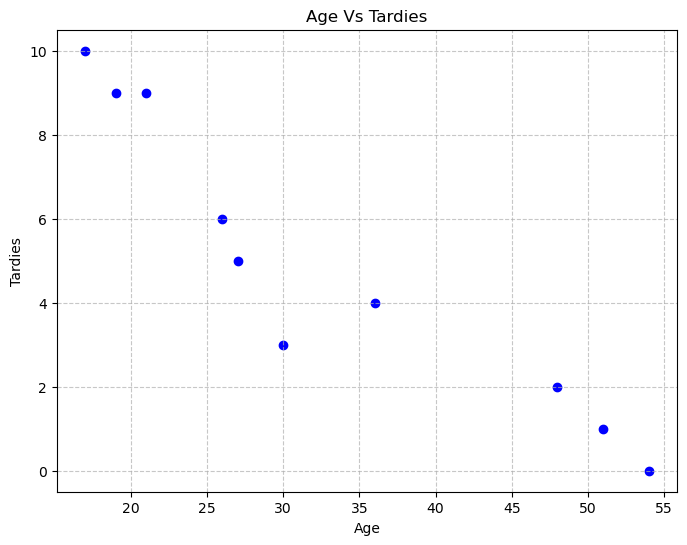

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(student_data['Age'], student_data['Tardies'], color='blue', marker='o')

plt.title('Age Vs Tardies')
plt.xlabel('Age')
plt.ylabel('Tardies')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

It seems negative linear relation, When people is getting older people use to not be late.

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [4]:
cov = student_data['Age'].cov(student_data['Tardies'])
corr = student_data['Age'].corr(student_data['Tardies'])

print(f"Covariance: {cov}")
print(f"Correlation: {corr}")

Covariance: -45.56666666666666
Correlation: -0.9391626886887122


1. COVARIANCE $ CORRELAtION:
   - Covariance: Relation between 2 variables, and measure the direction between them.
   - Correlatión: Relation between 2 variables and quantifies the strength and direction between them. Range values are from 1 to -1
     

2. COMPARISOM:
   - Covariance is -45.5666. It is a negative value, so they have a inverse relation.
   - Correlation is -0.94. It means they have a strong relation.

Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [5]:
from sklearn.linear_model import LinearRegression


X = student_data[['Age']]
y = student_data['Tardies']

model = LinearRegression()

model.fit(X, y)

# Predict values to visualize the regression line
y_pred = model.predict(X)

# Output the model coefficients
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_[0]}")

Intercept: 12.888803363135768
Coefficient: -0.2428207709159808


- I will use Simple Linear Regression because we are modeling the linear relationship between 2 continuous variables, Age as a independent variable and Tardies, dependent variable.
- Outcome variable is Tardies.

- Coefficient is -0.24, this value indicates how changes the variable for each age value.
- Intercept is 12.89, this value indicates wich value has the outcome variable when age is 0.


Plot your regression model on your scatter plot.

Text(0.5, 1.0, 'Simple Linear Regression: Age vs Tardies')

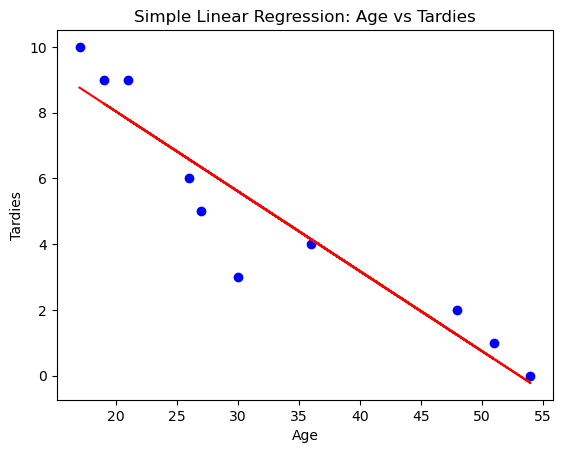

In [6]:
plt.scatter(X, y, color='blue')
plt.plot(X, y_pred, color='red')
plt.xlabel('Age')
plt.ylabel('Tardies')
plt.title('Simple Linear Regression: Age vs Tardies')

Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

The points are close to the fitted line, suggesting a good linear fit.

In conclusion, age is a good predictor of tardiness in this dataset, but we need more data to confirm.  

## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [7]:
# Import any libraries you may need & the data
vehicles = pd.read_csv("../vehicles.csv")

Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [8]:
vehicles.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


In [9]:

col_selected = vehicles[['Year', 'Cylinders', 'Fuel Barrels/Year', 'Combined MPG', 'Fuel Cost/Year', 'CO2 Emission Grams/Mile']]


ordered_corr = col_selected.corr().abs()['CO2 Emission Grams/Mile'].sort_values(ascending=False)
print(ordered_corr)

CO2 Emission Grams/Mile    1.000000
Fuel Barrels/Year          0.986189
Fuel Cost/Year             0.930865
Combined MPG               0.926229
Cylinders                  0.752393
Year                       0.222300
Name: CO2 Emission Grams/Mile, dtype: float64


Most relevant Feature is Fuel Barrels/Year (0.96)
Leat Important Feature is Year (0.22)

Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

X = col_selected.drop(columns=['CO2 Emission Grams/Mile'])

y = col_selected['CO2 Emission Grams/Mile']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Multiple Linear Regreesion with scaled variables

Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

R2 Score Train: 0.9812
R2 Score Test: 0.9795
RMSE : 17.0243


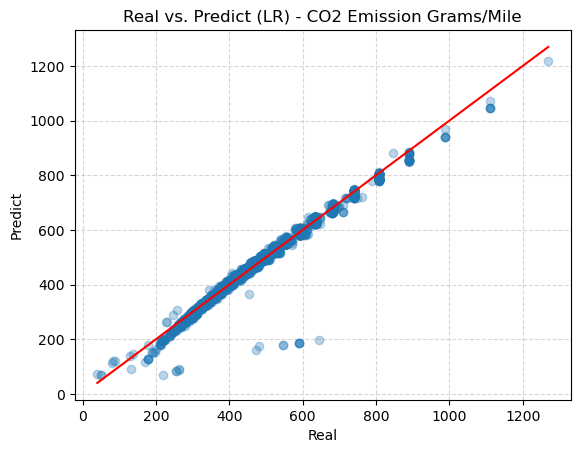

In [11]:
# Start and run the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

r2_train = lr_model.score(X_train_scaled, y_train)
r2_test = lr_model.score(X_test_scaled, y_test)
y_pred = lr_model.predict(X_test_scaled)


rmse_lr = root_mean_squared_error(y_test, y_pred)


print(f"R2 Score Train: {r2_train:.4f}")
print(f"R2 Score Test: {r2_test:.4f}")

print(f"RMSE : {rmse_lr:.4f}")


plt.plot(y_test, lr_model.predict(X_test_scaled), "o", alpha=0.3)

limits = [y_test.min(), y_test.max()]
plt.plot(limits, limits, 'r') 

plt.title("Real vs. Predict (LR) - CO2 Emission Grams/Mile")
plt.xlabel("Real")
plt.ylabel("Predict")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [12]:

coef_df = pd.Series(lr_model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(coef_df)

Fuel Barrels/Year    85.919670
Fuel Cost/Year       16.243277
Combined MPG        -15.047689
Year                 -3.181599
Cylinders             3.153042
dtype: float64


The most important feature is Fuel Barrels/Year (85.92), it's correlation, 0.96, confirms its consistent. 
Year and Cylinders are the least important features and their low correlation confirm it.


## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

In [ ]:
# Your code here.

Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

In [ ]:
# Your code here.

What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

*your explanation here*

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

In [ ]:
# Your response here.

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

*your explanation here*